In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps

from pathlib import Path
print(np.__version__)

1.26.4


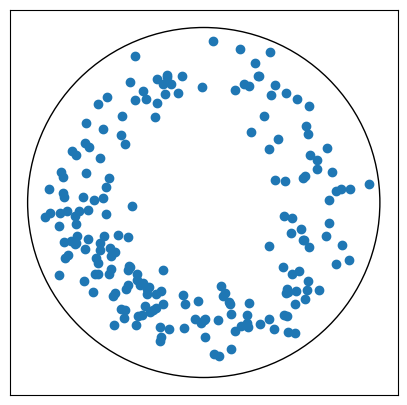

In [2]:
def perturb_points_inside_disc(points, R, noise_scale, seed=None, margin=1e-9):

    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, noise_scale, size=points.shape)
    perturbed_points = points + noise

    radii = np.linalg.norm(perturbed_points, axis=1)
    outside_boundary = radii > R
    if np.any(outside_boundary):
        scale = (R - margin) / radii[outside_boundary]
        perturbed_points[outside_boundary] *= scale[:, None]

    return perturbed_points

radius = 150
original_acc = np.loadtxt("/gpfs/bwfor/work/ws/hd_gy283-my_data/data_vMB/vMB_configs/acceptors.txt")

fig, ax = plt.subplots(figsize=(5,5))
circle = ps.Circle(xy=(0., 0.), radius=radius, fill=None)

ax.scatter(*original_acc.T)
ax.set_xticks([])
ax.set_yticks([])
ax.add_patch(circle)

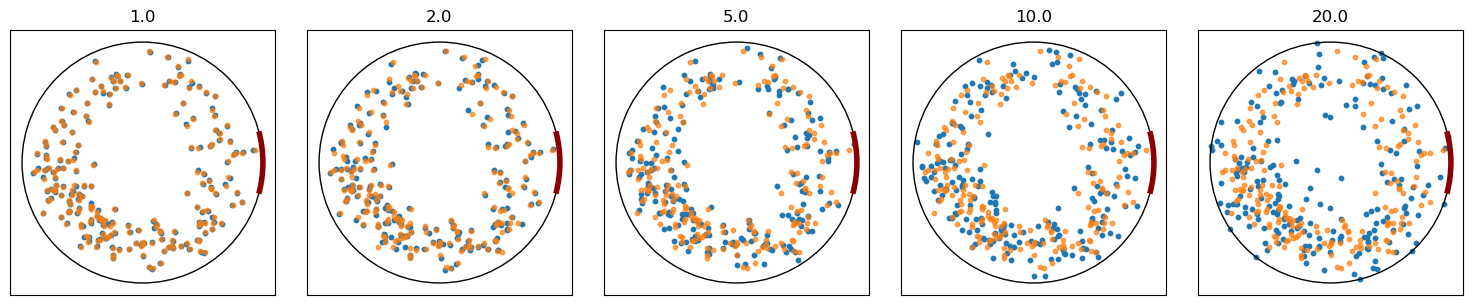

In [25]:
noise_levels = [1.0, 2.0, 5.0, 10.0, 20.0]#np.linspace(0.5, 10, 50)
fig, axs = plt.subplots(ncols=len(noise_levels), figsize=(3 * len(noise_levels), 3))
circle_kwargs = {
    "xy": (0, 0),
    "radius": radius,
    "fill": None
}

#save_dir = Path("/gpfs/bwfor/work/ws/hd_gy283-my_data/perturbation_experiment_configs")
#save_dir.mkdir(parents=True, exist_ok=True)

perturbed_acc_list = []
for noise in noise_levels:
    perturbed_acc = perturb_points_inside_disc(original_acc, radius, noise, seed=None, margin=1e-6)
    perturbed_acc_list.append(perturbed_acc)
    np.savetxt(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/perturbation_experiment_configs/acc_{noise}.txt", perturbed_acc, fmt="%6f", delimiter="\t")

arcs = []
    
for i in range(len(noise_levels)):

    axs[i].set_aspect("equal")
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].scatter(*perturbed_acc_list[i].T, s=10)
    axs[i].scatter(*original_acc.T, alpha=.7, s=10)
    axs[i].add_patch(ps.Circle(**circle_kwargs))
    axs[i].set_title(f"{noise_levels[i]}")
    
    axs[i].add_patch(ps.Arc((0, 0), width=2*radius, height=2*radius, theta1=345, theta2=15, color="darkred", linewidth=4))
plt.tight_layout()

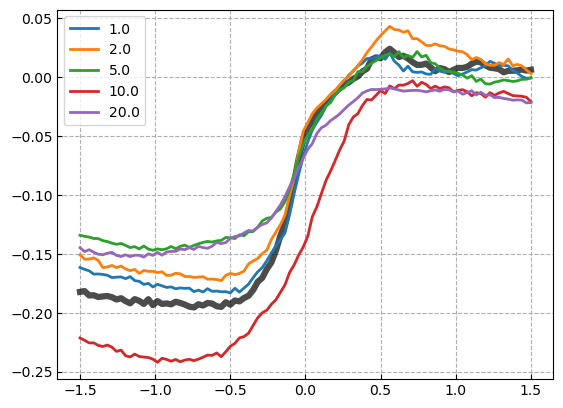

In [48]:
x = np.linspace(-1.5, 1.5, 100)

fig, ax = plt.subplots()
for n in noise_levels:
    data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/perturbation_experiment/vMB_n={n}.npz")
    ax.plot(x, data["current"], lw=2, zorder=4, label=n)
    ax.tick_params(direction="in")
    ax.grid(which="major", linestyle="dashed")
    ax.legend()

original = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/perturbation_experiment/vMB_no_noise.npz")
ax.plot(x, original["current"], lw=4.5, alpha=.7, c="k", zorder=3)

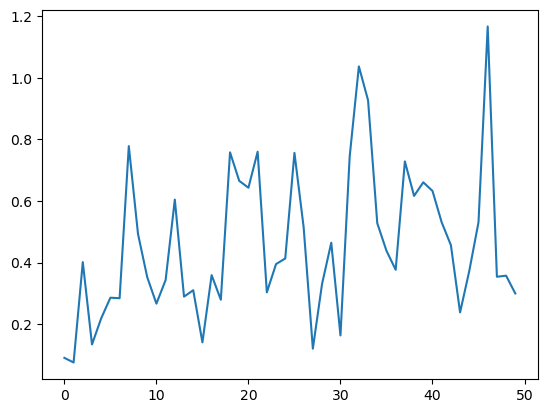

In [74]:
def target_function(t):
    N = t.shape[0]
    return 1 / (1 + np.exp(-7*t))
    
#y = target_function(x).reshape(-1, 1)
#y_norm = (y - y.mean()) / y.std()
#y_norm.reshape(-1, 1)
y_data = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/robustness_to_noisy_acceptors/sim_vMB_no_noise.npz")
y = y_data["current"].reshape(-1, 1)
y_norm = (y - y.mean()) / y.std()
rmse_vals = []
for i in range(noise_levels.shape[0]):
    data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/robustness_to_noisy_acceptors/sim_vMB_{i}.npz")
    I = data["current"].reshape(-1, 1)
    I_norm = (I - y.mean()) / y.std()
    I_norm.reshape(-1, 1)
    
    rmse = np.sqrt(np.mean((y_norm - I_norm)**2))
    rmse_vals.append(rmse)

plt.plot(rmse_vals)